In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import pandas as pd
from datetime import datetime
import seaborn as sns
from sklearn.linear_model import LinearRegression
from typing import Dict, Tuple

import os
from tqdm import tqdm
import fitz

def pdfshow(path):
    doc = fitz.open(path)
    page = doc[0]

    pix = page.get_pixmap(dpi=400)

    img = np.frombuffer(pix.samples, dtype=np.uint8)
    img = img.reshape(pix.height, pix.width, pix.n)
    return img

def show(post_1, post_2):
    plt.subplots(1, 4, figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(pdfshow(f"plots/{post_1}_{post_2}/figure_type_1.pdf"))
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(pdfshow(f"plots/{post_1}_{post_2}/figure_type_1_opacity_70.pdf"))
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pdfshow(f"plots/{post_1}_{post_2}/figure_type_2.pdf"))
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(pdfshow(f"plots/{post_1}_{post_2}/figure_type_3.pdf"))
    plt.axis("off")
    plt.show()

In [2]:
post_info_df = pd.read_csv("configs/post_info.csv", index_col=False)

In [3]:
post_info_df

,file_name,name_eng,name_rus,H
0,AKTAU.csv,Aktau,Актау,-28.000
1,ASHOR.csv,Ashuradeh,Ашураде,-27.147
2,BAKU.csv,Baku,Баку,-28.000
3,BEK.csv,Bekdash,Бекдаш,-28.000
4,ISB.csv,Izberbash,Избербаш,-28.000
5,KBG.csv,Kara-Bogaz-Gol,Кара-Богаз-Гол,-28.000
6,KRASN.csv,Krasnovodsk,Красноводск,-28.000
7,KUL.csv,Kulaly,Кулалы,-28.000
8,KUULI.csv,Kuuli-Mayak,Куули-маяк,-28.000
9,LAG.csv,Lagan,Лагань,-28.000


In [4]:
statistics = pd.read_csv('statistics.csv')

In [5]:
statistics

,NAME_1 EN,NAME_2 EN,NAME_1 RUS,NAME_2 RUS,NAME_1 EN_big,NAME_1 EN_big.1,NAME_1 RUS_big,NAME_2 RUS_big,Period for 1st post,Period for 2nd post,...,Figure_3,Figure_4,N,a,b,bias,SD,RMSE,r,R2
0,Aktau,Ashuradeh,Актау,Ашураде,AKTAU,ASHURADEH,АКТАУ,АШУРАДЕ,1961-2023,2008-2015,...,Aktau_Ashuradeh/figure_type_2.pdf,Aktau_Ashuradeh/figure_type_3.pdf,82,1.007661,-0.855017,-1.058110,0.053839,1.059479,0.971188,0.943206
1,Aktau,Baku,Актау,Баку,AKTAU,BAKU,АКТАУ,БАКУ,1961-2023,1900-2023,...,Aktau_Baku/figure_type_2.pdf,Aktau_Baku/figure_type_3.pdf,732,0.949305,-1.621957,-0.217604,0.175812,0.279753,0.967655,0.936355
2,Aktau,Bekdash,Актау,Бекдаш,AKTAU,BEKDASH,АКТАУ,БЕКДАШ,1961-2023,1930-2023,...,Aktau_Bekdash/figure_type_2.pdf,Aktau_Bekdash/figure_type_3.pdf,674,0.938057,-1.780067,-0.048537,0.170057,0.176848,0.971017,0.942873
3,Aktau,Izberbash,Актау,Избербаш,AKTAU,IZBERBASH,АКТАУ,ИЗБЕРБАШ,1961-2023,1949-1980,...,Aktau_Izberbash/figure_type_2.pdf,Aktau_Izberbash/figure_type_3.pdf,232,0.818461,-5.137888,0.052820,0.084773,0.099882,0.954043,0.910198
4,Aktau,Kara-Bogaz-Gol,Актау,Кара-Богаз-Гол,AKTAU,KARA-BOGAZ-GOL,АКТАУ,КАРА-БОГАЗ-ГОЛ,1961-2023,1921-2023,...,Aktau_Kara-Bogaz-Gol/figure_type_2.pdf,Aktau_Kara-Bogaz-Gol/figure_type_3.pdf,746,0.917234,-2.308237,0.004345,0.129096,0.129169,0.986079,0.972352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,Anzali,Ogurchinskiy,Энзели,Огурчинский,ANZALI,OGURCHINSKIY,ЭНЗЕЛИ,ОГУРЧИНСКИЙ,1941-2021,1938-2023,...,Anzali_Ogurchinskiy/figure_type_2.pdf,Anzali_Ogurchinskiy/figure_type_3.pdf,900,0.998695,0.956982,0.993475,0.139841,1.003268,0.974501,0.949653
522,Anzali,Peshnoy,Энзели,Пешной,ANZALI,PESHNOY,ЭНЗЕЛИ,ПЕШНОЙ,1941-2021,1929-2023,...,Anzali_Peshnoy/figure_type_2.pdf,Anzali_Peshnoy/figure_type_3.pdf,782,1.022541,1.533761,0.908426,0.251617,0.942629,0.918721,0.844048
523,Anzali,Sumgait,Энзели,Сумгаит,ANZALI,SUMGAIT,ЭНЗЕЛИ,СУМГАИТ,1941-2021,1948-2018,...,Anzali_Sumgait/figure_type_2.pdf,Anzali_Sumgait/figure_type_3.pdf,765,0.896927,-1.995866,0.878958,0.133158,0.888987,0.984805,0.969841
524,Anzali,Fereydunkenar,Энзели,Феридункенар,ANZALI,FEREYDUNKENAR,ЭНЗЕЛИ,ФЕРИДУНКЕНАР,1941-2021,2012-2021,...,Anzali_Fereydunkenar/figure_type_2.pdf,Anzali_Fereydunkenar/figure_type_3.pdf,89,0.920714,-1.900112,0.242780,0.075469,0.254239,0.948675,0.899984


In [6]:
list_of_posts = [
    ('Aktau', 'Neka'),
    ('Aktau', 'Izberbash'),
    ('Aktau', 'Ashuradeh'),
    ('Ashuradeh', 'Anzali'),
    ('Cheleken', 'Neftyanye Kamni'),
    ('Baku', 'Bekdash'),
    ('Ashuradeh', 'Neka'),
    ('Izberbash', 'Lagan'),
    ('Izberbash', 'Krasnovodsk'),
    ('Lagan', 'Anzali'),
    ('Aktau', 'Peshnoy'),
    ('Nowshahr', 'Fereydunkenar'),
    ('Izberbash', 'Baku'),
    ('Krasnovodsk','Fort-Shevchenko'),
    ('Izberbash', 'Fort-Shevchenko'),
    ('Kuuli-Mayak','Bekdash')
]

   Period for 1st post Period for 2nd post Period of joint time  \
11           1961-2023           1998-2011            1998-2011   

   Scatter plot period  
11           1998-2011  


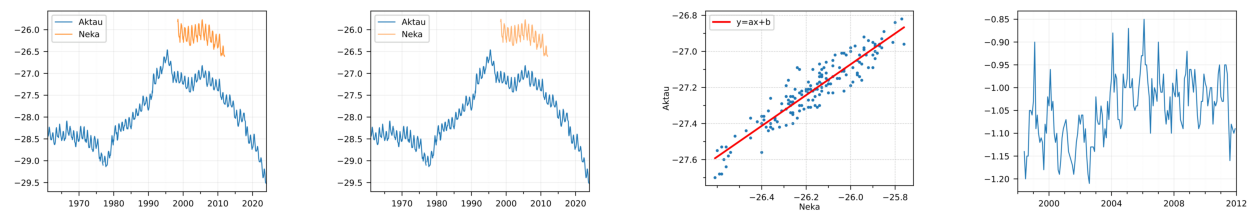

  Period for 1st post Period for 2nd post Period of joint time  \
3           1961-2023           1949-1980            1961-1980   

  Scatter plot period  
3           1961-1980  


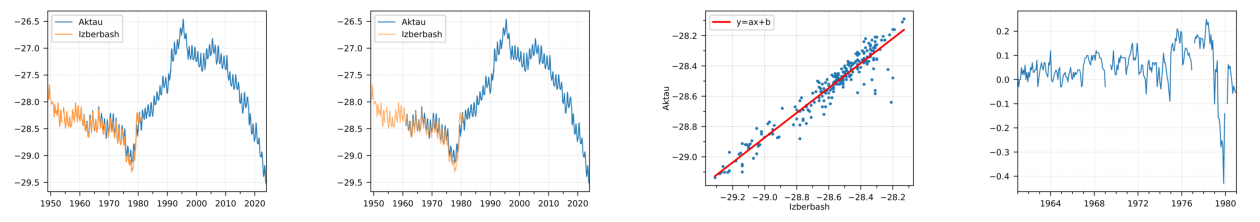

  Period for 1st post Period for 2nd post Period of joint time  \
0           1961-2023           2008-2015            2008-2015   

  Scatter plot period  
0           2008-2015  


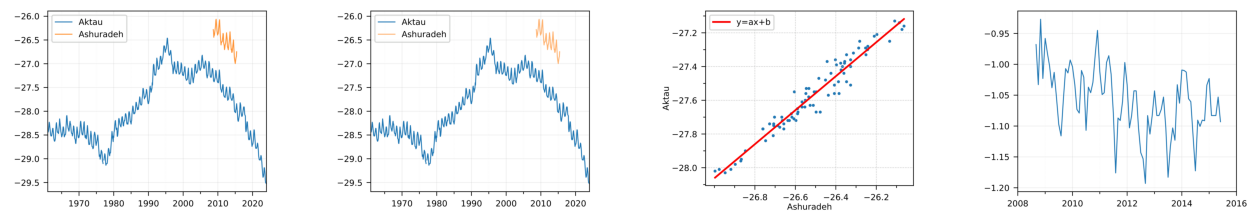

   Period for 1st post Period for 2nd post Period of joint time  \
43           2008-2015           1941-2021            2008-2015   

   Scatter plot period  
43           2008-2015  


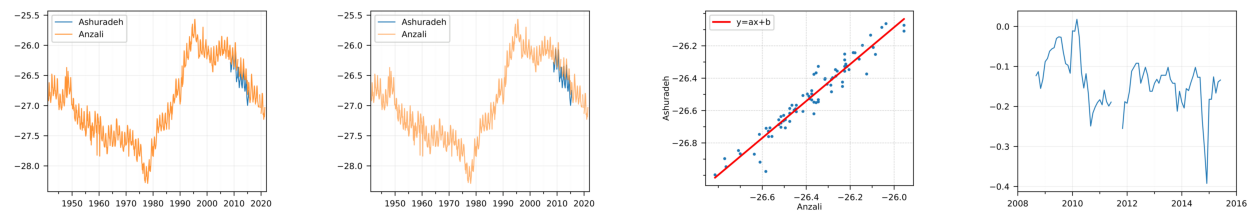

    Period for 1st post Period for 2nd post Period of joint time  \
498           2023-2023           1953-2023            2023-2023   

    Scatter plot period  
498           2023-2023  


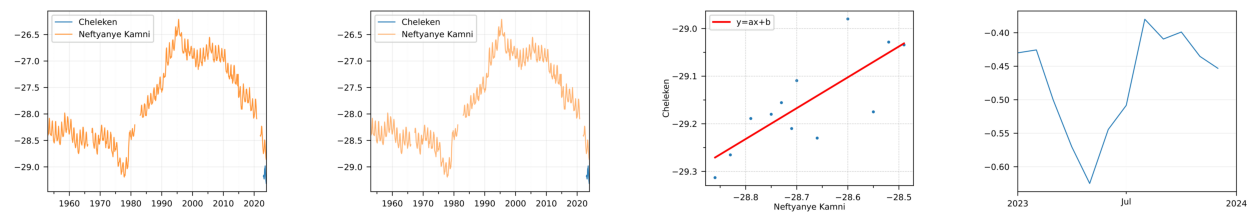

   Period for 1st post Period for 2nd post Period of joint time  \
46           1900-2023           1930-2023            1930-2023   

   Scatter plot period  
46           1930-2023  


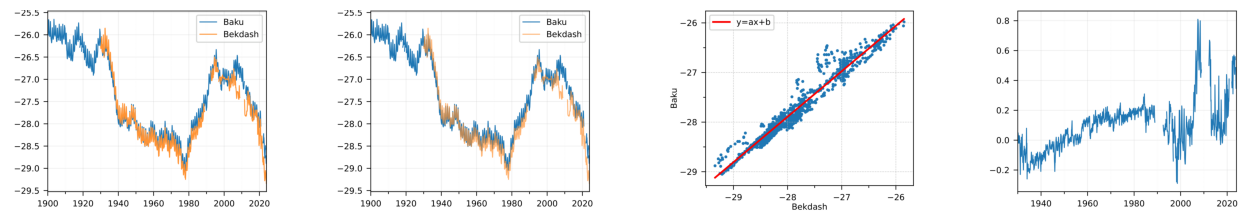

   Period for 1st post Period for 2nd post Period of joint time  \
33           2008-2015           1998-2011            2008-2011   

   Scatter plot period  
33           2008-2011  


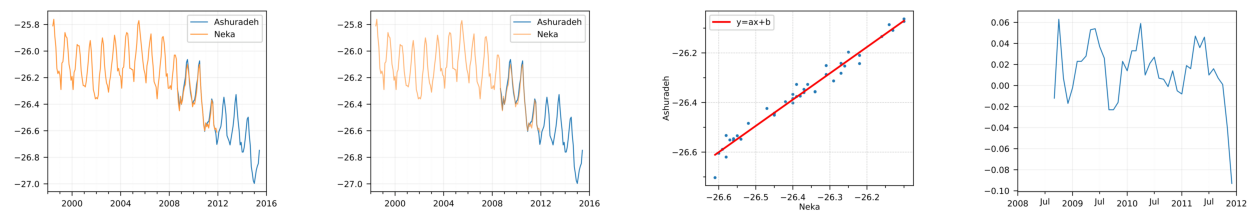

   Period for 1st post Period for 2nd post Period of joint time  \
97           1949-1980           1972-2023            1972-1980   

   Scatter plot period  
97           1972-1980  


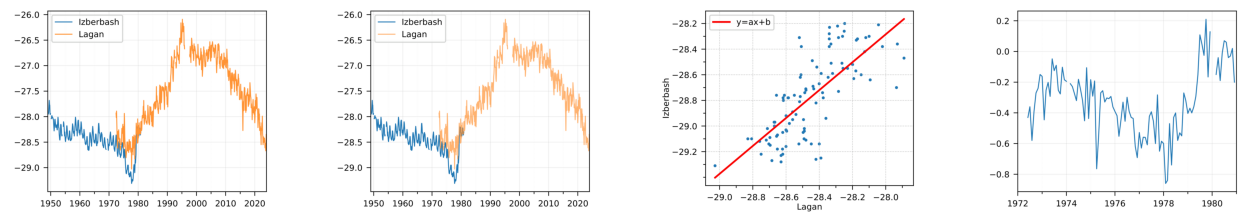

   Period for 1st post Period for 2nd post Period of joint time  \
94           1949-1980           1915-2023            1949-1980   

   Scatter plot period  
94           1949-1980  


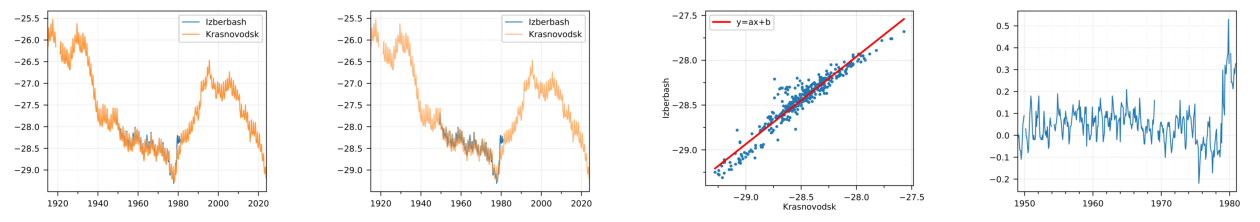

    Period for 1st post Period for 2nd post Period of joint time  \
222           1972-2023           1941-2021            1972-2021   

    Scatter plot period  
222           1972-2021  


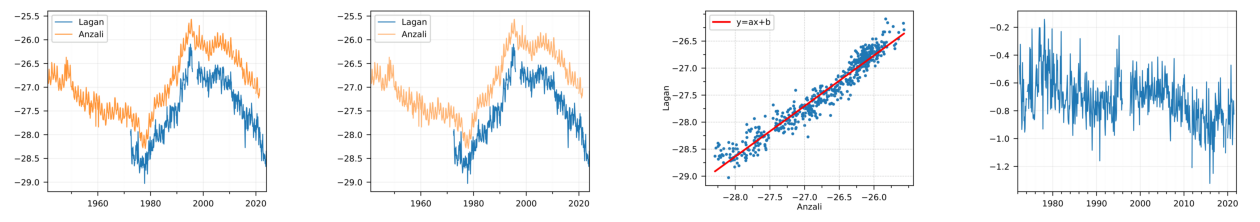

   Period for 1st post Period for 2nd post Period of joint time  \
17           1961-2023           1929-2023            1961-2023   

   Scatter plot period  
17           1961-2023  


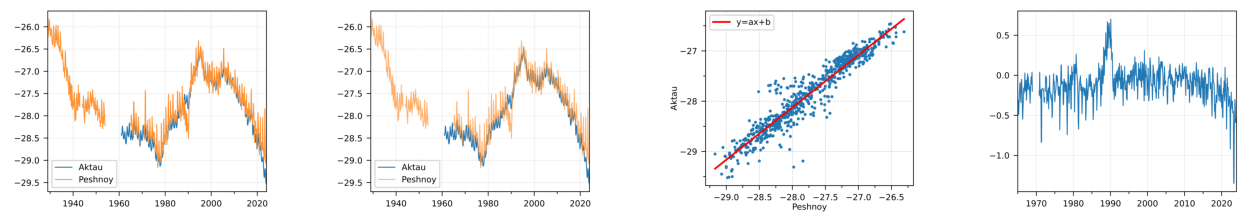

    Period for 1st post Period for 2nd post Period of joint time  \
329           2001-2014           2012-2021            2012-2014   

    Scatter plot period  
329           2012-2014  


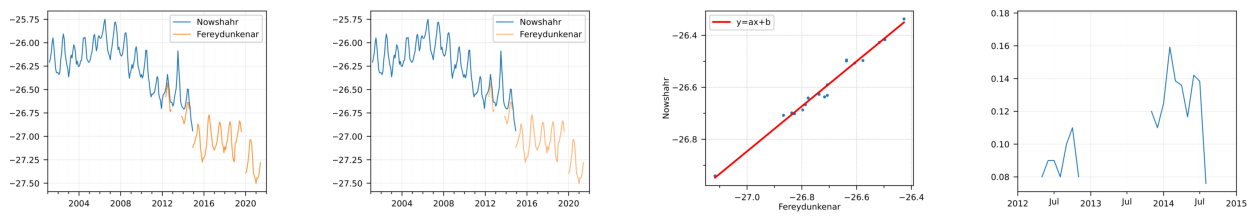

   Period for 1st post Period for 2nd post Period of joint time  \
91           1949-1980           1900-2023            1949-1980   

   Scatter plot period  
91           1949-1980  


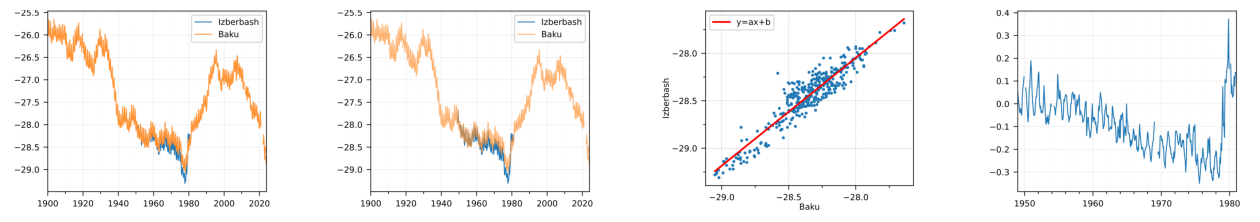

    Period for 1st post Period for 2nd post Period of joint time  \
151           1915-2023           1921-2023            1921-2023   

    Scatter plot period  
151           1921-2023  


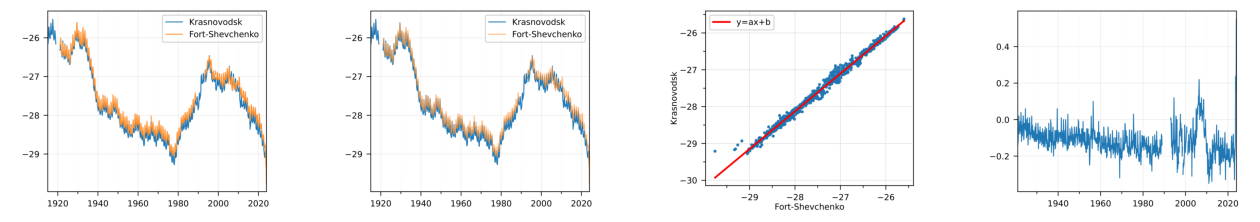

    Period for 1st post Period for 2nd post Period of joint time  \
106           1949-1980           1921-2023            1949-1980   

    Scatter plot period  
106           1949-1980  


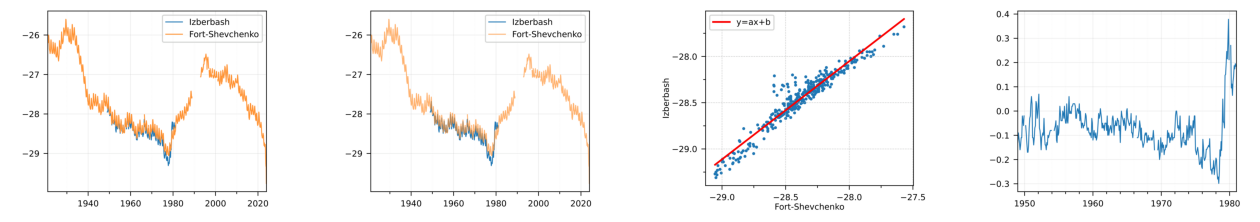

    Period for 1st post Period for 2nd post Period of joint time  \
180           1900-2023           1930-2023            1930-2023   

    Scatter plot period  
180           1930-2023  


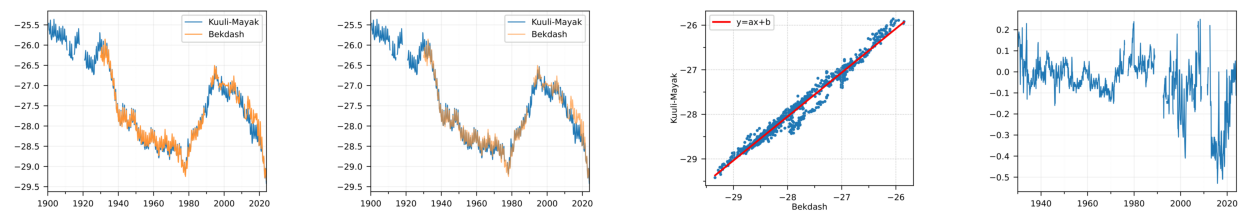

In [7]:
for pair in list_of_posts:
    
    print(statistics[(statistics['NAME_1 EN']==pair[0])&(statistics['NAME_2 EN']==pair[1])][['Period for 1st post', 'Period for 2nd post', 'Period of joint time', 'Scatter plot period']])
    show(*pair)